In [1]:
import NEXT
import NEXT.wforecast as wfc
import os
import matplotlib.pyplot as plt
import pandas as pd
import geopandas as gpd
from pynhd import WaterData, NLDI
from time import sleep
import warnings
import numpy as np
import datetime

# Prepare Environment

In [2]:
dirs = ["hist_data/", "hrrr_data/", "final_hist/", "gfs_raw/", "forecasts/"]
for d in dirs:
    if not os.path.exists(d):
        os.mkdir(d)

# Identify Sites

By default, the forecast runs for 1,000 HUC-12 pour points sampled from across the contiguous US. You can modify this by changing the site selection below and removing the cached site file. The sampling procedure is to select 1,000 different HUC-8s, then sample one HUC-12 from each. (The actual default dataset contains 935 sites.)

In [3]:
sitefile = "forecast_points.json"
run_sites = not os.path.exists(sitefile)

In [4]:
def try_and_sleep(f):
    sleep(5)
    try:
        return f()
    except:
        return None

# Wait between calls because otherwise it tends to overload the API
if run_sites:
    huc6 = WaterData("wbd06")
    huc12 = WaterData("wbd12")
    all_huc6 = huc6.bybox((-125, 25, -65, 50))
    huc12_samp = pd.concat([
        try_and_sleep(lambda: huc12.bygeom(x.geometry).sample(n=50)) # get extra samples because some will crash
        for x in all_huc6.itertuples()
    ]).sample(n=1200)
    pps = NLDI().getfeature_byid("huc12pp", huc12_samp["huc12"])
    geodata = (huc12_samp.loc[:, ["geometry", "huc12", "areasqkm"]].
        rename(columns={"huc12": "id", "areasqkm": "area"}).
        merge(
            pd.DataFrame({
                "id": pps["identifier"],
                "lat": pps.geometry.y,
                "lon": pps.geometry.x
            }),
            on="id"
        )).dropna().sample(1000)
    geodata.loc[:, "area"] = geodata["area"] * 1e6 # km2 -> m2
    geodata.to_file(sitefile)

else:
    geodata = gpd.read_file(sitefile)

<Axes: >

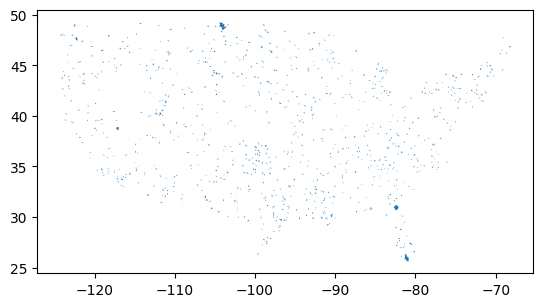

In [5]:
geodata.plot()

# Retrieve Historical Data

Humidity is retrieved from GridMet. Air temperature is from HRRR so that climatology will be more similar to GFS, for which NEXT doesn't have long-term archive retrieval (just recent forecast runs).

The below loops may crash periodically due to server errors. If so, just restart them, as they are set up to resume where they left off. GridMet retrieval takes several hours, and HRRR retrieval is currently exceptionally slow for no obvious reason, on the order of 1 hour per site. Due to that challenge, HRRR is only retrieved for one year for a sample of sites, which is used to fit a correction function.

In [6]:
runhist = len(os.listdir(dirs[2])) == 0

In [7]:
basepath = dirs[0] + "/"
if runhist:
    with warnings.catch_warnings(action="ignore"):
        for row in geodata.itertuples():
            fn = basepath + row.id + ".csv"
            if not os.path.exists(fn):
                # note: site type "huc12" doesn't actually exist. It will internally convert to coordinates.
                try:
                    NEXT.data.geom_full_data(row.id, "huc12", gpd.GeoSeries([row.geometry], crs=4326), row.lat, row.lon, row.area,
                                             "2015", "2025", "gridmet").to_csv(fn, index=False)
                except:
                    print(row.id)

The following block can be cancelled after several dozen sites have been retrieved.

In [8]:
if runhist:
    allids = [x.split('.')[0] for x in os.listdir(dirs[0])]  # don't run HRRR if we don't have other info
    basepath = dirs[1] + '/'
    with warnings.catch_warnings(action="ignore"):
        for row in geodata.itertuples():
            fn = basepath + row.id + ".csv"
            if (not os.path.exists(fn)) and (row.id in allids):
                NEXT.data.weather_hrrr(gpd.GeoSeries([row.geometry], crs=4326), "2025-01-01", "2025-12-31").to_csv(fn, index=False)

Compute corrections:

In [9]:
allids = [x.split('.')[0] for x in os.listdir(dirs[1])]
combined = pd.concat([
    pd.read_csv(dirs[0] + "/" + row.id + ".csv", parse_dates=["date"]).
        merge(pd.read_csv(dirs[1] + "/" + row.id + ".csv", parse_dates=["date"]),
              on="date",
              suffixes=["_gm", "_hrrr"])
    for row in geodata.itertuples()
    if row.id in allids
])

<Axes: xlabel='tmax_gm', ylabel='tmax_hrrr'>

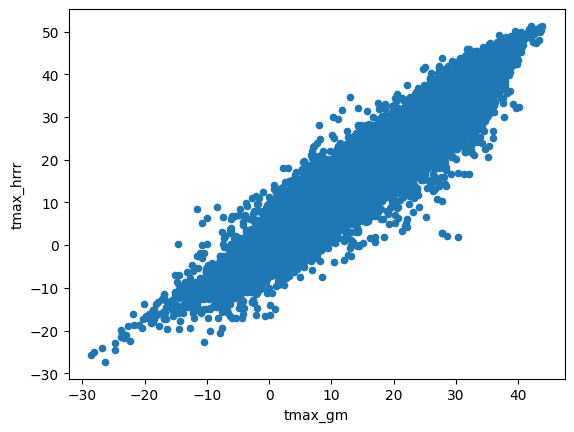

In [10]:
combined.plot.scatter(x="tmax_gm", y="tmax_hrrr")

In [11]:
combined["tmax_gm"].corr(combined["tmax_hrrr"])

np.float64(0.9543465835168514)

In [12]:
(combined.groupby("id")[["tmax_hrrr", "tmax_gm"]].corr().
    loc[(slice(None), "tmax_gm"), "tmax_hrrr"].describe())

count    78.000000
mean      0.945189
std       0.037704
min       0.762891
25%       0.935038
50%       0.956855
75%       0.967331
max       0.978917
Name: tmax_hrrr, dtype: float64

The relationship is imperfect, but we observe that sitewise correlation is nearly identical to global correlation, so a global correction can be applied.

In [13]:
fit = np.linalg.lstsq(
    np.array([np.ones(len(combined)), combined["tmax_gm"]]).T,
    combined["tmax_hrrr"])[0]

In [14]:
if runhist:
    for fn in os.listdir(dirs[0]):
        if fn.endswith('.csv'):
            data = pd.read_csv(dirs[0] + "/" + fn, parse_dates=["date"])
            data["tmax"] = data["tmax"] * fit[1] + fit[0]
            data.to_csv(dirs[2] + '/' + fn, index=False)

# Retrieve Forecast Data and Execute Forecasts

Note that this may be quite memory-intensive. There's a memory leak somewhere. However, as everything is set to resume where it left off, it is safe to restart the kernel when memory use becomes excessive.

In [15]:
model = NEXT.NEXT.from_pickle('coefs_hrrr.pickle')

In [ ]:
allids = [x.split('.')[0] for x in os.listdir(dirs[2])]
torun = geodata.loc[geodata['id'].isin(allids)]
earlier = (datetime.date.today() - datetime.timedelta(6)).strftime("%Y%m%d")
today = datetime.date.today().strftime("%Y%m%d")
end = (datetime.date.today() + datetime.timedelta(16)).strftime("%Y-%m-%d")
# (geom, lat, lon, area) = NEXT.data.geom_fns[get_site_type(site)](site)
def get_gfs(row):
    geom = gpd.GeoSeries([row.geometry], crs=4326)
    recent_weath = pd.DataFrame(wfc.get_gfs_downloaded(geom, earlier, dirs[3])).reset_index()
    fcst_weath = pd.DataFrame(wfc.get_gfs_downloaded(geom, today, dirs[3])).reset_index()
    res = pd.concat([fcst_weath, recent_weath]).groupby("date", as_index=False)["tmax"].first().sort_values("date")
    res["id"] = row.id
    return res
with warnings.catch_warnings(action='ignore'):
    for row in torun.itertuples():
        infn = dirs[2] + row.id + '.csv'
        outfn = dirs[4] + row.id + '_' + today + '.csv'
        if not os.path.exists(outfn):
            try:
                model.make_newt(pd.read_csv(infn, parse_dates=['date']), reset=True)
                model.run(get_gfs(row)).to_csv(outfn, index=False)
            except KeyboardInterrupt:
                break
            except:
                print(row.id)